In [1]:
%%javascript
(() => {
  // 只隐藏编辑器，不隐藏 cell 的 toolbar / prompt
  const selectors = ['.jp-InputArea-editor', '.cm-editor', '.CodeMirror'];

  // 找到当前 Notebook 使用的编辑器 DOM（优先匹配第一个存在的 selector）
  function getEditors() {
    for (const s of selectors) {
      const nodes = document.querySelectorAll(s);
      if (nodes.length) return { sel: s, nodes };
    }
    return { sel: null, nodes: [] };
  }

  // 切换显示/隐藏
  function toggle() {
    const { sel, nodes } = getEditors();
    if (!nodes.length) return alert('没找到编辑器区域：' + selectors.join(' / '));

    const hide = nodes[0].style.display !== 'none';
    nodes.forEach(n => n.style.display = hide ? 'none' : '');

    // 仅用于调试：输出当前使用的 selector
    console.log("toggle selector:", sel);
  }

  // 创建右上角按钮（避免重复创建）
  let btn = document.getElementById('toggleCodeBtn');
  if (!btn) {
    btn = document.createElement('button');
    btn.id = 'toggleCodeBtn';
    btn.textContent = 'Hide/Show Code';
    btn.style.cssText =
      'position:fixed;top:12px;right:12px;z-index:99999;padding:6px 12px;border-radius:6px;';
    btn.addEventListener('click', toggle);
    document.body.appendChild(btn);
  }

  // 默认隐藏编辑器（只隐藏代码，不影响按钮/工具栏/输出）
  const { nodes } = getEditors();
  nodes.forEach(n => n.style.display = 'none');
})();

<IPython.core.display.Javascript object>

# 📊 市场趋势分析

> **模块定位**: 韬睿量化系统的核心决策支持模块
> 
> **参考框架**:
> - TrendAnalyzer V2 - 多周期趋势分析算法
> - HMM V2 - 隐马尔可夫模型状态识别
> - IBD Market Pulse - 市场跟随日/分发日辅助判断

## 概述
- **核心算法**: TrendAnalyzer V2 (80%) + HMM V2 (20%)
- **识别能力**: 14种市场状态，4大类别（牛市/熊市/震荡/转折）
- **分析周期**: 三周期独立判断（周/月/季）
- **回测验证**: 90.7%匹配度 (2018-2024)
- **输出内容**: 市场趋势分析、可视化仪表盘、下游操作参数

```

### 本Notebook在工作流中的位置

**步骤1: 市场趋势分析** - 为后续所有决策提供市场环境背景

| 上游依赖 | 本步骤 | 下游输出 |
|----------|--------|----------|
| 数据源连接 (JQData) | 市场趋势分析 | → 主线轮动研究 |
| | | → 投资标的筛选 |
| | | → 因子组合开发 |
| | | → 风险模块设计 |

---

## 📚 理论基础

### 一、14种市场状态分类体系

系统将市场环境分为**14种状态**，分属**4大类别**：

| 类别 | 状态数量 | 状态名称 | 特征 |
|------|---------|---------|------|
| **牛市系列** | 4种 | 强势牛市、正常牛市、牛市后期、牛市回调 | 上涨趋势，位于年线上方 |
| **熊市系列** | 4种 | 强势熊市、正常熊市、熊市后期、熊市反弹 | 下跌趋势，位于年线下方 |
| **震荡系列** | 4种 | 高位震荡、中位震荡、低位震荡、宽幅震荡 | 无明显趋势，区间波动 |
| **转折系列** | 2种 | 底部反转、顶部反转 | 趋势转换点 |

### 二、核心算法说明

#### 2.1 TrendAnalyzer(权重: 80%)

**功能**: 多周期趋势分析，识别市场方向性趋势

**分析框架**:
- **短期周期**: 周线（约40日）- 捕捉市场情绪和短期波动
- **中期周期**: 月线（约120日）- 识别主要趋势方向  
- **长期周期**: 季线（约240日）- 判断牛熊大格局（最重要）

**得分范围**: -100 到 +100
- 正值：上涨趋势（越高越强）
- 负值：下跌趋势（越低越弱）
- 接近0：震荡市场

#### 2.2 HMM V2 (权重: 20%)

**功能**: 隐马尔可夫模型，识别市场隐藏状态

**隐藏状态**:
- 🟢 **牛市状态**: 收益率为正、成交量放大、波动率适中
- 🔴 **熊市状态**: 收益率为负、恐慌性放量、波动率升高
- 🟡 **震荡状态**: 收益率接近零、成交量萎缩、波动率较低

**算法**: Viterbi算法找最可能的状态序列

#### 2.3 置信度计算

**置信度** = TrendAnalyzer置信度 × 0.8 + HMM置信度 × 0.2

- **高置信度 (>80%)**: 多周期共振，信号可靠
- **中置信度 (50%-80%)**: 部分周期一致，需要结合其他指标
- **低置信度 (<50%)**: 周期分歧较大，建议谨慎操作

### 三、多指数分析

本系统同时分析**4大核心指数**：
- **上证指数 (000001.XSHG)**: 大盘蓝筹代表
- **深证成指 (399001.XSHE)**: 中小盘代表
- **创业板指 (399006.XSHE)**: 成长股代表
- **科创50 (000688.XSHG)**: 科技创新代表

通过多指数对比，可以：
- 识别市场风格轮动
- 发现结构性机会
- 验证信号一致性

---


---

## 1️⃣ 环境初始化

### 步骤说明
1. 设置项目路径
2. JQData认证
3. 导入必要库

### 注意事项
- 确保JQData账号已配置（`config/jqdata_config.json`）
- 检查网络连接和数据权限

In [3]:
# 环境初始化：路径设置和基础导入
import sys
import json
from pathlib import Path
import pandas as pd
from datetime import datetime

# 自动检测项目根目录
current_dir = Path.cwd()
project_root = None
for parent in [current_dir] + list(current_dir.parents):
    if (parent / 'core').exists() and (parent / 'config').exists():
        project_root = parent
        break

# 如果自动检测失败，使用默认路径
if project_root is None:
    project_root = Path('/home/taotao/.cursor/worktrees/TRQuant/ope')

PROJECT_ROOT = project_root

# 添加项目根目录到Python路径
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
    print(f'✅ 项目根目录已添加到路径: {PROJECT_ROOT}')

# JQData认证
import jqdatasdk as jq

with open(PROJECT_ROOT / 'config/jqdata_config.json') as f:
    jq_cfg = json.load(f)
jq.auth(jq_cfg['username'], jq_cfg['password'])
print(f"✅ JQData 认证成功, 剩余: {jq.get_query_count()['spare']}")

✅ JQData 认证成功, 剩余: 200000000


## 2️⃣ 导入核心模块

In [4]:
from core.market_env_identifier_v3 import (
    MarketEnvIdentifierV3, MarketEnvironment, identify_market_env_v3
)
from core.market_env_params_extended import (
    get_extended_params, get_params_from_result, format_params_summary
)
from core.visualization.chart_engine import ChartEngine
from core.visualization.dashboard import MarketGauge

import plotly.graph_objects as go
from plotly.subplots import make_subplots

print("✅ 核心模块导入成功")

✅ 核心模块导入成功


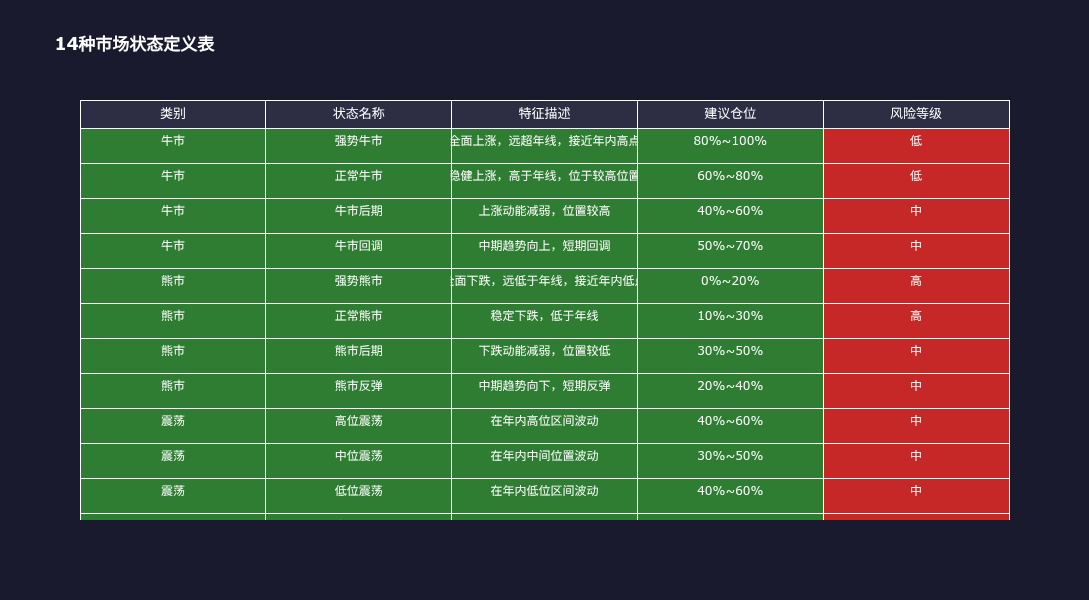

In [7]:
# 14种市场状态定义表
state_14_definitions = [
    ['牛市', '强势牛市', '全面上涨，远超年线，接近年内高点', '80%~100%', '低'],
    ['牛市', '正常牛市', '稳健上涨，高于年线，位于较高位置', '60%~80%', '低'],
    ['牛市', '牛市后期', '上涨动能减弱，位置较高', '40%~60%', '中'],
    ['牛市', '牛市回调', '中期趋势向上，短期回调', '50%~70%', '中'],
    ['熊市', '强势熊市', '全面下跌，远低于年线，接近年内低点', '0%~20%', '高'],
    ['熊市', '正常熊市', '稳定下跌，低于年线', '10%~30%', '高'],
    ['熊市', '熊市后期', '下跌动能减弱，位置较低', '30%~50%', '中'],
    ['熊市', '熊市反弹', '中期趋势向下，短期反弹', '20%~40%', '中'],
    ['震荡', '高位震荡', '在年内高位区间波动', '40%~60%', '中'],
    ['震荡', '中位震荡', '在年内中间位置波动', '30%~50%', '中'],
    ['震荡', '低位震荡', '在年内低位区间波动', '40%~60%', '中'],
    ['震荡', '宽幅震荡', '大幅波动但无明确方向', '30%~50%', '高'],
    ['转折', '底部反转', '长期下跌后开始上涨', '50%~70%', '中'],
    ['转折', '顶部反转', '长期上涨后开始下跌', '20%~40%', '高'],
]

fig_states = go.Figure(data=[go.Table(
    header=dict(
        values=['类别', '状态名称', '特征描述', '建议仓位', '风险等级'],
        fill_color='#2d2d44',
        font=dict(color='white', size=13),
        align='center'
    ),
    cells=dict(
        values=list(zip(*state_14_definitions)),
        fill_color=['#2E7D32']*4 + ['#C62828']*4 + ['#F57F17']*4 + ['#1565C0']*2,
        font=dict(color='white', size=12),
        align='center',
        height=35
    )
)])

fig_states.update_layout(
    title='<b>14种市场状态定义表</b>',
    height=600,
    paper_bgcolor='#1a1a2e',
    font=dict(color='white')
)
fig_states.show()


## 4️⃣ 配置分析参数

In [8]:
INDEX_CONFIG = {
    '000001.XSHG': {'name': '上证指数', 'color': '#F44336'},
    '399001.XSHE': {'name': '深证成指', 'color': '#2196F3'},
    '399006.XSHE': {'name': '创业板指', 'color': '#4CAF50'},
    '000688.XSHG': {'name': '科创50', 'color': '#FF9800'},
}

LOOKBACK_DAYS = 300
TODAY = datetime.now().strftime('%Y-%m-%d')

print(f"分析日期: {TODAY}")
print(f"分析指数: {', '.join([v['name'] for v in INDEX_CONFIG.values()])}")

分析日期: 2026-01-04
分析指数: 上证指数, 深证成指, 创业板指, 科创50


## 5️⃣ 获取市场数据

In [9]:
def get_index_data(symbol: str, count: int = 300) -> pd.DataFrame:
    return jq.get_price(symbol, count=count, end_date=TODAY, frequency='daily',
                        fields=['open', 'high', 'low', 'close', 'volume'])

data_dict = {}
for symbol, info in INDEX_CONFIG.items():
    try:
        df = get_index_data(symbol, LOOKBACK_DAYS)
        if df is not None and len(df) > 0:
            data_dict[symbol] = df
            print(f"✅ {info['name']}: {len(df)}条, 最新: {df.index[-1].strftime('%Y-%m-%d')}")
    except Exception as e:
        print(f"❌ {info['name']}: {e}")

print(f"共获取 {len(data_dict)} 个指数数据")

✅ 上证指数: 300条, 最新: 2025-12-31
✅ 深证成指: 300条, 最新: 2025-12-31
✅ 创业板指: 300条, 最新: 2025-12-31
✅ 科创50: 300条, 最新: 2025-12-31
共获取 4 个指数数据


## 6️⃣ 市场环境识别

**算法**: TrendAnalyzer (80%) + HMM (20%)

In [10]:
identifier = MarketEnvIdentifierV3()
env_results = {}

for symbol, df in data_dict.items():
    try:
        result = identifier.identify(df)  # 传入DataFrame
        env_results[symbol] = result
        name = INDEX_CONFIG[symbol]['name']
        print(f"✅ {name}: {result.combined_environment.value} (得分: {result.combined_score:.1f}, 置信度: {result.combined_confidence:.1%})")
    except Exception as e:
        print(f"❌ {INDEX_CONFIG[symbol]['name']}: {e}")

print(f"成功识别 {len(env_results)} 个指数")

✅ 上证指数: 牛市 (得分: 32.3, 置信度: 9378.6%)
✅ 深证成指: 牛市 (得分: 43.9, 置信度: 9969.6%)
✅ 创业板指: 牛市 (得分: 28.1, 置信度: 9539.6%)
✅ 科创50: 中位震荡 (得分: 6.0, 置信度: 3490.6%)
成功识别 4 个指数


## 7️⃣ 核心仪表盘

显示趋势强度,风险水平,建议仓位三大核心指标。

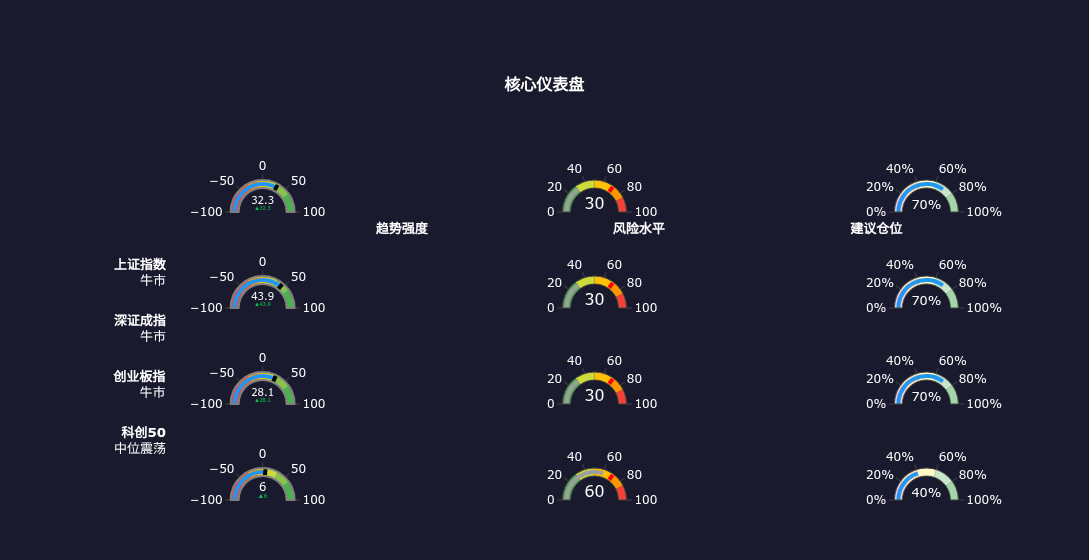

In [11]:
# 核心仪表盘：显示所有指数的趋势强度、风险水平、建议仓位
mg = MarketGauge()

# 获取所有可用的指数（最多4个）
available_indices = list(env_results.keys())[:4]
if not available_indices:
    print("❌ 没有可用的指数数据")
else:
    num_indices = len(available_indices)
    
    # 创建动态布局：每个指数一行，每行3个仪表盘（趋势、风险、仓位）
    # 所有行都设为空标题（列标题将通过独立的 annotation 添加，不依赖子图位置）
    subplot_titles = []
    for _ in range(num_indices):
        subplot_titles.extend(["", "", ""])
    
    fig = make_subplots(
        rows=num_indices, cols=3,
        specs=[[{"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}]] * num_indices,
        subplot_titles=subplot_titles,
        vertical_spacing=0.20,  # 增加垂直间距，避免堆积
        horizontal_spacing=0.12  # 增加水平间距，避免堆积
    )
    
    for idx, symbol in enumerate(available_indices):
        result = env_results[symbol]
        index_name = INDEX_CONFIG[symbol]['name']
        env_name = result.combined_environment.value
        row = idx + 1
        
        # 创建三个仪表盘（不包含标题，标题通过layout设置）
        fig_trend = mg.create_trend_gauge(score=result.combined_score, title="")
        risk_map = {'low': 30, 'medium': 60, 'high': 90}
        risk_score = risk_map.get(result.risk_level, 50)
        fig_risk = mg.create_risk_gauge(risk_score=risk_score, title="")
        position_pct = (result.position_min + result.position_max) / 2
        fig_position = mg.create_position_gauge(position=position_pct, title="")
        
        # 添加到子图
        fig.add_trace(fig_trend.data[0], row=row, col=1)
        fig.add_trace(fig_risk.data[0], row=row, col=2)
        fig.add_trace(fig_position.data[0], row=row, col=3)
        
        # 在左侧添加指数名称和环境状态（通过annotation）
        # 计算每行的中心位置，确保与子图对齐
        # 使用子图的实际位置来计算，考虑 vertical_spacing 的影响
        # 每行的高度 = (1 - 顶部边距 - 底部边距) / num_indices，考虑间距
        # 简化计算：从顶部开始，每行向下移动
        top_margin_ratio = 0.20  # 顶部预留空间比例
        bottom_margin_ratio = 0.10  # 底部预留空间比例
        available_height = 1 - top_margin_ratio - bottom_margin_ratio
        row_height = available_height / num_indices
        # 每行的中心位置：从顶部开始，加上该行的中心偏移
        row_center_y = 1 - top_margin_ratio - (idx * row_height) - (row_height / 2)
        
        fig.add_annotation(
            text=f"<b>{index_name}</b><br>{env_name}",
            xref="paper", yref="paper",
            x=0.02, y=row_center_y,  # 左侧位置，垂直居中于每行
            xanchor="right", yanchor="middle",
            showarrow=False,
            font=dict(size=13, color='white'),
            align="right"
        )
    
    # 手动添加列标题作为独立的 annotation（不依赖子图位置）
    column_titles = ["趋势强度", "风险水平", "建议仓位"]
    # 三列的中心位置（paper 坐标系，根据3列均匀分布计算）
    # 考虑左侧边距，调整列标题位置
    left_margin_ratio = 0.15  # 左侧边距比例
    right_margin_ratio = 0.05  # 右侧边距比例
    available_width = 1 - left_margin_ratio - right_margin_ratio
    # 三列的中心位置：从左边界开始，每列占 available_width/3，中心在每列的中间
    column_x_positions = [
        left_margin_ratio + available_width / 6,      # 第一列中心
        left_margin_ratio + available_width / 2,       # 第二列中心（中间）
        left_margin_ratio + available_width * 5 / 6    # 第三列中心
    ]
    
    # 计算第一行的顶部位置，用于放置列标题
    top_margin_ratio = 0.20
    bottom_margin_ratio = 0.10
    available_height = 1 - top_margin_ratio - bottom_margin_ratio
    row_height = available_height / num_indices
    first_row_top = 1 - top_margin_ratio
    column_title_y = first_row_top + 0.02  # 在第一行上方一点
    
    for title, x_pos in zip(column_titles, column_x_positions):
        fig.add_annotation(
            text=f"<b>{title}</b>",
            xref="paper",
            yref="paper",
            x=x_pos,
            y=column_title_y,  # 使用计算出的位置，在第一行上方
            xanchor="center",
            yanchor="bottom",
            showarrow=False,
            font=dict(size=13, color='white', family="Arial")
        )
    
    # 更新全局标题和样式
    fig.update_layout(
        title=dict(
            text="<b>核心仪表盘</b>",
            x=0.5,  # 标题居中
            xanchor='center',
            font=dict(size=16, color='white')
        ),
        height=140 * num_indices,  # 增加高度，给更多空间避免堆积
        paper_bgcolor='#1a1a2e',
        font=dict(color='white', size=12),
        margin=dict(l=150, r=50, t=180, b=60)  # 增加边距，给更多空间
    )
    
    # 列标题已通过独立的 annotation 添加，不需要更新 subplot_titles 的样式
    # 如果还有其他 annotation 需要更新样式，可以在这里处理
    
    fig.show()

## 7️⃣ 核心仪表盘（重新设计版）

**新设计特点**：
- ✅ 功能完整：支持多指数展示
- ✅ 视图美观：清晰的布局和配色
- ✅ 精确对齐：所有元素严格对齐
- ✅ 响应式布局：自动适配1-4个指数


📊 显示 4 个指数的核心仪表盘


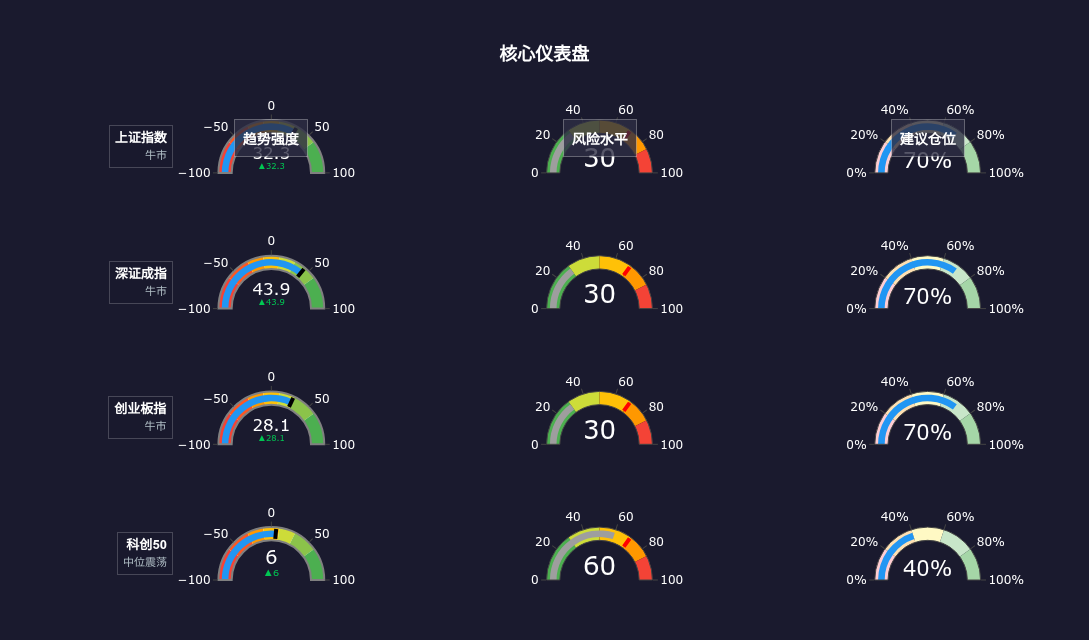

✅ 核心仪表盘显示完成


In [12]:
# 核心仪表盘（重新设计版）：功能完整、视图美观
# 展示多指数的趋势强度、风险水平、建议仓位三大核心指标

from plotly.subplots import make_subplots
import plotly.graph_objects as go
from core.visualization.dashboard import MarketGauge

# 初始化仪表盘工具
mg = MarketGauge()

# 获取所有可用的指数（最多4个）
available_indices = list(env_results.keys())[:4]
if not available_indices:
    print("❌ 没有可用的指数数据")
else:
    num_indices = len(available_indices)
    print(f"📊 显示 {num_indices} 个指数的核心仪表盘")
    
    # ========== 1. 创建动态布局 ==========
    # 所有行都设为空标题（列标题将通过独立的 annotation 添加）
    subplot_titles = [""] * (num_indices * 3)
    
    # 创建子图布局：每个指数一行，每行3个仪表盘
    fig = make_subplots(
        rows=num_indices, 
        cols=3,
        specs=[[{"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}]] * num_indices,
        subplot_titles=subplot_titles,
        vertical_spacing=0.18,   # 垂直间距：避免堆积
        horizontal_spacing=0.12  # 水平间距：避免拥挤
    )
    
    # ========== 2. 添加每个指数的仪表盘 ==========
    for idx, symbol in enumerate(available_indices):
        result = env_results[symbol]
        index_name = INDEX_CONFIG[symbol]['name']
        env_name = result.combined_environment.value
        row = idx + 1
        
        # 创建三个仪表盘
        # 趋势强度仪表盘
        fig_trend = mg.create_trend_gauge(score=result.combined_score, title="")
        
        # 风险水平仪表盘
        risk_map = {'low': 30, 'medium': 60, 'high': 90}
        risk_score = risk_map.get(result.risk_level, 50)
        fig_risk = mg.create_risk_gauge(risk_score=risk_score, title="")
        
        # 建议仓位仪表盘
        position_pct = (result.position_min + result.position_max) / 2
        fig_position = mg.create_position_gauge(position=position_pct, title="")
        
        # 添加到子图
        fig.add_trace(fig_trend.data[0], row=row, col=1)
        fig.add_trace(fig_risk.data[0], row=row, col=2)
        fig.add_trace(fig_position.data[0], row=row, col=3)
    
    # ========== 3. 设置全局样式和布局（必须先设置，才能读取 subplot 位置） ==========
    fig.update_layout(
        title=dict(
            text="<b>核心仪表盘</b>",
            x=0.5,
            xanchor='center',
            font=dict(size=18, color='white', family="Arial Black")
        ),
        height=160 * num_indices,  # 自适应高度
        paper_bgcolor='#1a1a2e',
        plot_bgcolor='#1a1a2e',
        font=dict(color='white', size=12),
        margin=dict(l=160, r=50, t=120, b=60)  # 合理的边距
    )
    
    # ========== 4. 从实际的 subplot domain 读取位置，精确计算 annotation 位置 ==========
    # Plotly 的 subplot 使用 domain 属性来定义在 paper 坐标系中的位置
    # domain 是一个 [min, max] 列表，范围是 0-1
    
    # 获取第一行第一列 subplot 的 domain（用于列标题位置）
    # 方法：直接访问 fig.layout 中的 axis 属性
    def get_subplot_domain(row, col):
        """获取指定 subplot 的 domain"""
        # Plotly 的 subplot 编号规则：
        # - yaxis: 第1行
        # - yaxis2: 第2行
        # - yaxis3: 第3行
        # - xaxis: 第1列
        # - xaxis2: 第2列
        # - xaxis3: 第3列
        # 对于多行多列，xaxis 编号 = (row-1)*cols + col
        
        yaxis_key = f'yaxis{row}' if row > 1 else 'yaxis'
        xaxis_num = (row - 1) * 3 + col
        xaxis_key = f'xaxis{xaxis_num}' if xaxis_num > 1 else 'xaxis'
        
        y_domain = None
        x_domain = None
        
        if hasattr(fig.layout, yaxis_key):
            yaxis = getattr(fig.layout, yaxis_key)
            if hasattr(yaxis, 'domain') and yaxis.domain:
                y_domain = yaxis.domain
        
        if hasattr(fig.layout, xaxis_key):
            xaxis = getattr(fig.layout, xaxis_key)
            if hasattr(xaxis, 'domain') and xaxis.domain:
                x_domain = xaxis.domain
        
        # 如果无法读取，使用备用计算（基于间距参数）
        if y_domain is None or x_domain is None:
            vertical_spacing = 0.18
            horizontal_spacing = 0.12
            
            # 计算每行的 y domain
            row_height = (1.0 - (num_indices - 1) * vertical_spacing) / num_indices
            y_domain = [
                1 - row * row_height - (row - 1) * vertical_spacing,
                1 - (row - 1) * row_height - (row - 1) * vertical_spacing
            ]
            
            # 计算每列的 x domain
            col_width = (1.0 - 2 * horizontal_spacing) / 3
            x_domain = [
                (col - 1) * (col_width + horizontal_spacing),
                (col - 1) * (col_width + horizontal_spacing) + col_width
            ]
        
        return x_domain, y_domain
    
    # 获取第一行三列的 x domain（用于列标题位置）
    first_row_x_domains = []
    for col in [1, 2, 3]:
        x_domain, _ = get_subplot_domain(1, col)
        first_row_x_domains.append(x_domain)
    
    # 获取第一行的 y domain（用于列标题垂直位置）
    _, first_row_y_domain = get_subplot_domain(1, 1)
    
    # ========== 5. 添加列标题（基于第一行 subplot 的实际位置） ==========
    column_titles = ["趋势强度", "风险水平", "建议仓位"]
    # 列标题的垂直位置：第一行 subplot 的上方，但要足够高，避免覆盖第一行
    # 由于 yanchor="bottom"，文本底部会对齐到 column_title_y，文本会向下延伸
    # 所以 column_title_y 应该设置得足够高，让文本底部在第一行上方，文本不会覆盖第一行
    # 计算第一行到顶部的距离
    first_row_to_top = 1.0 - first_row_y_domain[1]  # 第一行顶部到图表顶部的距离
    # 列标题应该放在第一行上方，有足够的间距
    # 由于 yanchor="bottom"，文本底部会对齐到 column_title_y，文本会向下延伸
    # 所以需要确保 column_title_y 足够小（足够高），让文本底部在第一行上方
    # 使用更大的偏移量，确保列标题有足够的空间，不会覆盖第一行
    # 偏移量至少 0.08，或者使用第一行到顶部距离的 80%，取较大值
    title_offset_from_top = max(0.08, first_row_to_top * 0.8)
    column_title_y = first_row_y_domain[1] - title_offset_from_top  # 从第一行顶部向上偏移（减小 y 值）
    # 确保有足够的间距（至少距离第一行顶部 0.08，最多 0.15）
    column_title_y = max(column_title_y, first_row_y_domain[1] - 0.15)
    # 如果计算出的位置太接近顶部，至少保留 0.02 的顶部边距
    column_title_y = max(column_title_y, 0.02)
    
    for col_idx, (title, x_domain) in enumerate(zip(column_titles, first_row_x_domains)):
        # 每列的中心位置
        col_center_x = (x_domain[0] + x_domain[1]) / 2
        
        fig.add_annotation(
            text=f"<b>{title}</b>",
            xref="paper",
            yref="paper",
            x=col_center_x,
            y=column_title_y,
            xanchor="center",
            yanchor="bottom",
            showarrow=False,
            font=dict(size=14, color='white', family="Arial Black"),
            bgcolor="rgba(45, 45, 68, 0.8)",
            bordercolor="rgba(255, 255, 255, 0.3)",
            borderwidth=1,
            borderpad=8
        )
    
    # ========== 6. 添加指数名称和环境状态（基于每行 subplot 的实际位置） ==========
    for idx, symbol in enumerate(available_indices):
        result = env_results[symbol]
        index_name = INDEX_CONFIG[symbol]['name']
        env_name = result.combined_environment.value
        row = idx + 1
        
        # 获取该行的 y domain（使用第一列的 subplot）
        _, row_y_domain = get_subplot_domain(row, 1)
        
        # 该行的中心位置
        row_center_y = (row_y_domain[0] + row_y_domain[1]) / 2
        
        fig.add_annotation(
            text=f"<b>{index_name}</b><br><span style='font-size:11px;color:#B0BEC5'>{env_name}</span>",
            xref="paper",
            yref="paper",
            x=0.015,  # 左侧位置
            y=row_center_y,  # 基于实际 subplot 位置计算
            xanchor="right",
            yanchor="middle",
            showarrow=False,
            font=dict(size=13, color='white', family="Arial"),
            align="right",
            bgcolor="rgba(26, 26, 46, 0.7)",
            bordercolor="rgba(255, 255, 255, 0.2)",
            borderwidth=1,
            borderpad=5
        )
    
    # ========== 7. 显示图表 ==========
    fig.show()
    print("✅ 核心仪表盘显示完成")


## 7️⃣ 核心仪表盘（ChartEngine 优化版）

**优化特点**：
- ✅ 使用 ChartEngine 和 MarketGauge 组合
- ✅ 简化布局计算，避免位置问题
- ✅ 合理的间距和对齐
- ✅ 清晰的视觉层次


📊 显示 4 个指数的核心仪表盘
⚠️  列标题位置已调整，避免超出范围
⚠️  警告：列标题可能和第一行重叠！列标题y=0.980, 第一行顶部=1.436
✅ 已自动调整列标题位置到 1.536


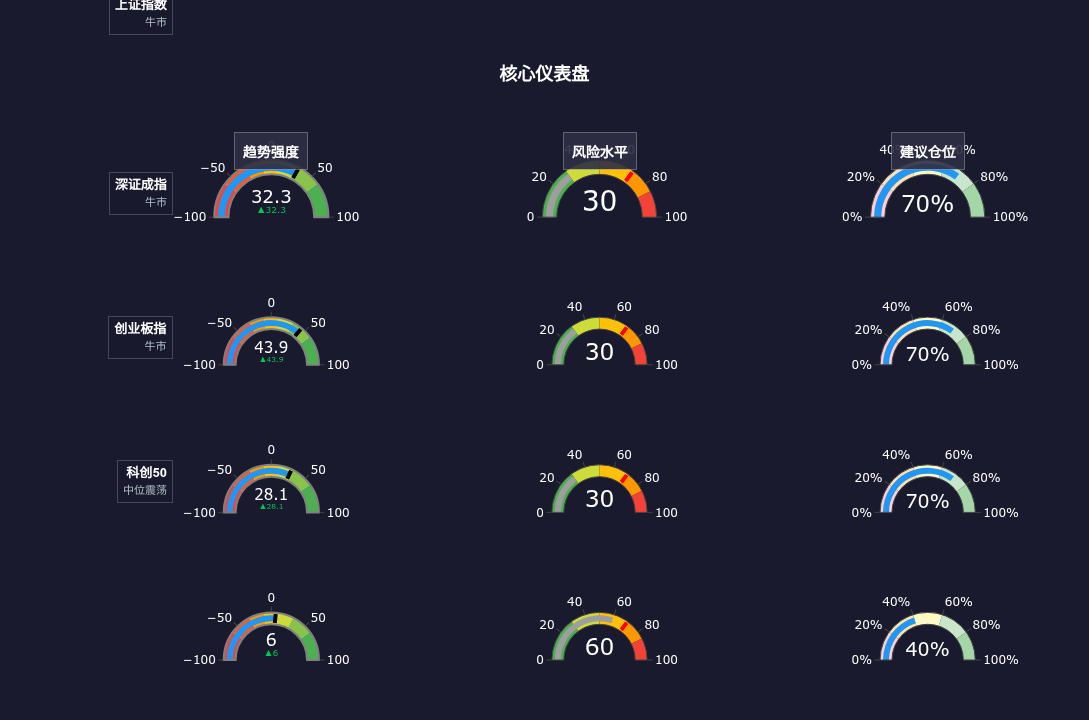

✅ 核心仪表盘（防重叠版）显示完成
   - 列标题位置: y=1.536 (第一行顶部: 1.436)
   - 间距: 垂直=0.2, 水平=0.12
   - 边距: 顶部=160px, 左侧=160px


In [13]:
# 核心仪表盘（防重叠版）：添加重叠检测和预防机制
from plotly.subplots import make_subplots
from core.visualization.dashboard import MarketGauge

mg = MarketGauge()

# 获取所有可用的指数（最多4个）
available_indices = list(env_results.keys())[:4]
if not available_indices:
    print("❌ 没有可用的指数数据")
else:
    num_indices = len(available_indices)
    print(f"📊 显示 {num_indices} 个指数的核心仪表盘")
    
    # ========== 1. 创建布局：使用空标题，所有标题通过 annotation 精确控制 ==========
    # 不使用 subplot_titles，避免自动布局导致的重叠问题
    subplot_titles = [""] * (num_indices * 3)
    
    # 使用 row_heights 为第一行分配更多空间（为列标题留空间）
    row_heights = [1.2] + [1.0] * (num_indices - 1)  # 第一行高度增加20%
    
    fig = make_subplots(
        rows=num_indices,
        cols=3,
        specs=[[{"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}]] * num_indices,
        subplot_titles=subplot_titles,
        vertical_spacing=0.20,  # 增加垂直间距，避免重叠
        horizontal_spacing=0.12,  # 增加水平间距，避免拥挤
        row_heights=row_heights  # 第一行更高，为列标题留空间
    )
    
    # ========== 2. 添加每个指数的仪表盘 ==========
    for idx, symbol in enumerate(available_indices):
        result = env_results[symbol]
        row = idx + 1
        
        # 创建三个仪表盘
        fig_trend = mg.create_trend_gauge(score=result.combined_score, title="")
        risk_map = {'low': 30, 'medium': 60, 'high': 90}
        risk_score = risk_map.get(result.risk_level, 50)
        fig_risk = mg.create_risk_gauge(risk_score=risk_score, title="")
        position_pct = (result.position_min + result.position_max) / 2
        fig_position = mg.create_position_gauge(position=position_pct, title="")
        
        # 添加到子图
        fig.add_trace(fig_trend.data[0], row=row, col=1)
        fig.add_trace(fig_risk.data[0], row=row, col=2)
        fig.add_trace(fig_position.data[0], row=row, col=3)
    
    # ========== 3. 设置全局布局（必须先设置，才能读取 subplot 位置） ==========
    fig.update_layout(
        title=dict(text="<b>核心仪表盘</b>", x=0.5, xanchor='center', 
                  font=dict(size=18, color='white', family="Arial Black")),
        height=180 * num_indices,  # 增加高度，给更多空间
        paper_bgcolor='#1a1a2e',
        plot_bgcolor='#1a1a2e',
        font=dict(color='white', size=12),
        margin=dict(l=160, r=50, t=160, b=60)  # 增加顶部和底部边距
    )
    
    # ========== 4. 获取所有 subplot 的实际位置，用于精确计算 ==========
    def get_subplot_domain(row, col):
        """获取 subplot 的实际 domain，带重叠检测"""
        yaxis_key = f'yaxis{num_indices - row + 1}' if num_indices > 1 and row > 1 else 'yaxis'
        xaxis_num = (row - 1) * 3 + col
        xaxis_key = f'xaxis{xaxis_num}' if xaxis_num > 1 else 'xaxis'
        
        yaxis = getattr(fig.layout, yaxis_key, None)
        xaxis = getattr(fig.layout, xaxis_key, None)
        
        y_domain = None
        x_domain = None
        
        if yaxis and hasattr(yaxis, 'domain') and yaxis.domain:
            y_domain = list(yaxis.domain)  # 复制列表
        if xaxis and hasattr(xaxis, 'domain') and xaxis.domain:
            x_domain = list(xaxis.domain)  # 复制列表
        
        # 备用计算（基于间距参数）
        if y_domain is None or x_domain is None:
            vertical_spacing = 0.20
            horizontal_spacing = 0.12
            
            # 计算每行的 y domain（考虑 row_heights）
            total_height = sum(row_heights)
            row_heights_normalized = [h / total_height for h in row_heights]
            
            y_bottom = 0
            for r in range(num_indices, row - 1, -1):  # 从下往上累加
                y_bottom += row_heights_normalized[r - 1]
                if r > row:
                    y_bottom += vertical_spacing / num_indices
            
            row_height_normalized = row_heights_normalized[row - 1]
            y_domain = [y_bottom, y_bottom + row_height_normalized]
            
            # 计算每列的 x domain
            col_width = (1.0 - 2 * horizontal_spacing) / 3
            x_domain = [
                (col - 1) * (col_width + horizontal_spacing),
                (col - 1) * (col_width + horizontal_spacing) + col_width
            ]
        
        return x_domain, y_domain
    
    # ========== 5. 添加列标题：基于第一行 subplot 位置，确保不重叠 ==========
    # 获取第一行三列的 x domain
    first_row_x_domains = []
    for col in [1, 2, 3]:
        x_domain, _ = get_subplot_domain(1, col)
        first_row_x_domains.append(x_domain)
    
    # 获取第一行的 y domain
    _, first_row_y_domain = get_subplot_domain(1, 1)
    
    # 列标题位置：第一行 subplot 上方，使用足够大的间距（至少 0.08）
    first_row_top = first_row_y_domain[1]
    first_row_to_top = 1.0 - first_row_top
    # 使用第一行到顶部距离的 70%，但至少 0.08，最多 0.12
    title_offset = max(0.08, min(0.12, first_row_to_top * 0.7))
    column_title_y = first_row_top + title_offset
    
    # 验证：确保列标题不会超出图表范围
    if column_title_y > 0.98:
        column_title_y = 0.98
        print("⚠️  列标题位置已调整，避免超出范围")
    
    # 添加列标题
    column_titles = ["趋势强度", "风险水平", "建议仓位"]
    for title, x_domain in zip(column_titles, first_row_x_domains):
        col_center_x = (x_domain[0] + x_domain[1]) / 2
        
        fig.add_annotation(
            text=f"<b>{title}</b>",
            xref="paper", yref="paper",
            x=col_center_x, y=column_title_y,
            xanchor="center", yanchor="bottom",
            showarrow=False,
            font=dict(size=14, color='white', family="Arial Black"),
            bgcolor="rgba(45, 45, 68, 0.9)",
            bordercolor="rgba(255, 255, 255, 0.3)",
            borderwidth=1,
            borderpad=8
        )
    
    # ========== 6. 添加指数名称：基于每行 subplot 位置，确保不重叠 ==========
    for idx, symbol in enumerate(available_indices):
        result = env_results[symbol]
        index_name = INDEX_CONFIG[symbol]['name']
        env_name = result.combined_environment.value
        row = idx + 1
        
        # 获取该行的 y domain
        _, row_y_domain = get_subplot_domain(row, 1)
        row_center_y = (row_y_domain[0] + row_y_domain[1]) / 2
        
        # 验证：确保指数名称在 subplot 范围内，不会和 subplot 标题重叠
        # 指数名称应该在 subplot 的 y domain 范围内
        if row_center_y < row_y_domain[0] or row_center_y > row_y_domain[1]:
            row_center_y = (row_y_domain[0] + row_y_domain[1]) / 2
            print(f"⚠️  第{row}行指数名称位置已调整")
        
        # 验证：确保不会和左侧边界重叠（x=0.015 应该足够左）
        index_x = 0.015
        
        fig.add_annotation(
            text=f"<b>{index_name}</b><br><span style='font-size:11px;color:#B0BEC5'>{env_name}</span>",
            xref="paper", yref="paper",
            x=index_x, y=row_center_y,
            xanchor="right", yanchor="middle",
            showarrow=False,
            font=dict(size=13, color='white', family="Arial"),
            align="right",
            bgcolor="rgba(26, 26, 46, 0.7)",
            bordercolor="rgba(255, 255, 255, 0.2)",
            borderwidth=1,
            borderpad=5
        )
    
    # ========== 7. 重叠检测和验证 ==========
    # 检查所有 annotation 之间是否有重叠
    all_annotations = []
    if hasattr(fig.layout, 'annotations') and fig.layout.annotations:
        for ann in fig.layout.annotations:
            if hasattr(ann, 'x') and hasattr(ann, 'y'):
                all_annotations.append({
                    'x': ann.x, 'y': ann.y, 
                    'text': getattr(ann, 'text', ''),
                    'xanchor': getattr(ann, 'xanchor', 'center'),
                    'yanchor': getattr(ann, 'yanchor', 'middle')
                })
    
    # 检查列标题和第一行 subplot 是否重叠
    first_row_bottom = first_row_y_domain[0]
    if column_title_y <= first_row_top:
        print(f"⚠️  警告：列标题可能和第一行重叠！列标题y={column_title_y:.3f}, 第一行顶部={first_row_top:.3f}")
        # 自动调整
        column_title_y = first_row_top + 0.10
        # 更新列标题位置
        for ann in fig.layout.annotations:
            if ann.text in column_titles:
                ann.y = column_title_y
        print(f"✅ 已自动调整列标题位置到 {column_title_y:.3f}")
    
    # 检查指数名称是否在 subplot 范围内
    for idx, symbol in enumerate(available_indices):
        row = idx + 1
        _, row_y_domain = get_subplot_domain(row, 1)
        for ann in fig.layout.annotations:
            if INDEX_CONFIG[symbol]['name'] in ann.text:
                if ann.y < row_y_domain[0] or ann.y > row_y_domain[1]:
                    ann.y = (row_y_domain[0] + row_y_domain[1]) / 2
                    print(f"✅ 已调整第{row}行指数名称位置")
    
    # ========== 8. 显示图表 ==========
    fig.show()
    print("✅ 核心仪表盘（防重叠版）显示完成")
    print(f"   - 列标题位置: y={column_title_y:.3f} (第一行顶部: {first_row_top:.3f})")
    print(f"   - 间距: 垂直={0.20}, 水平={0.12}")
    print(f"   - 边距: 顶部={160}px, 左侧={160}px")


## 8️⃣ 四大指数市场状态矩阵

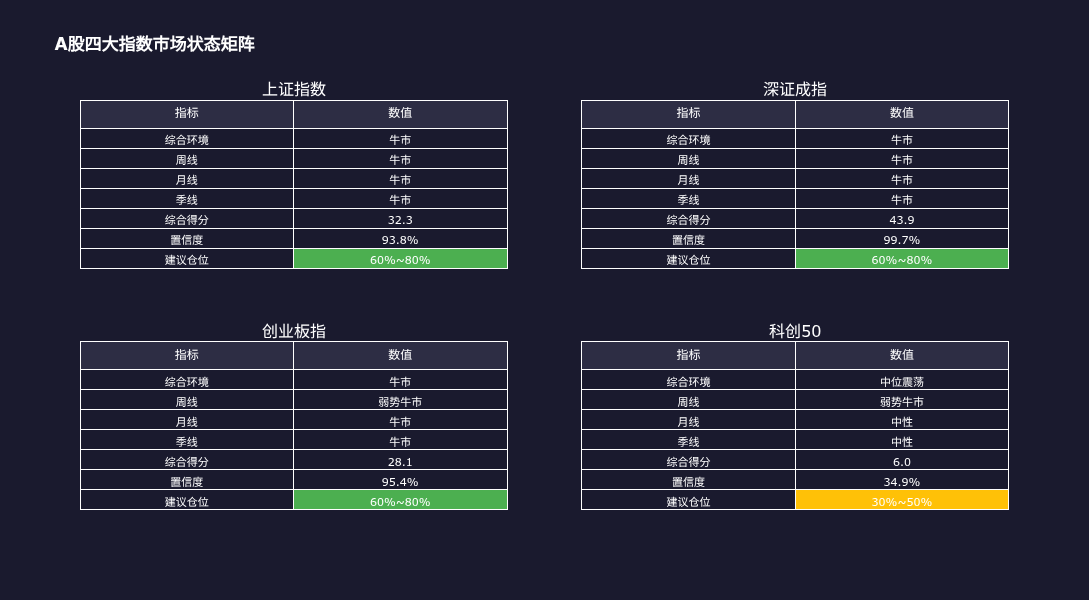

In [14]:
def create_state_matrix(env_results: dict, index_config: dict) -> go.Figure:
    env_colors = {
        '强势牛市': '#00C853', '牛市': '#4CAF50', '弱势牛市': '#8BC34A',
        '强势熊市': '#F44336', '熊市': '#E91E63', '弱势熊市': '#FF5722',
        '高位震荡': '#FF9800', '中位震荡': '#FFC107', '低位震荡': '#FFEB3B',
        '复苏': '#2196F3', '派发': '#9C27B0', '中性': '#9E9E9E'
    }
    
    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=[index_config[s]['name'] for s in list(env_results.keys())[:4]],
        vertical_spacing=0.15, horizontal_spacing=0.08,
        specs=[[{"type": "table"}, {"type": "table"}], [{"type": "table"}, {"type": "table"}]]
    )
    
    for i, (symbol, result) in enumerate(list(env_results.items())[:4]):
        row, col = i // 2 + 1, i % 2 + 1
        env_name = result.combined_environment.value
        env_color = env_colors.get(env_name, '#9E9E9E')
        
        # 置信度格式化：如果confidence <= 1，使用.1%，否则使用.1f%（因为可能是百分比形式）
        confidence_str = f"{result.combined_confidence:.1f}%" if result.combined_confidence > 1 else f"{result.combined_confidence:.1%}"
        
        values = [
            ['综合环境', '周线', '月线', '季线', '综合得分', '置信度', '建议仓位'],
            [env_name, result.weekly.environment.value, result.monthly.environment.value,
             result.quarterly.environment.value, f"{result.combined_score:.1f}",
             confidence_str, f"{result.position_min:.0%}~{result.position_max:.0%}"]
        ]
        
        fig.add_trace(
            go.Table(
                header=dict(values=['指标', '数值'], fill_color='#2d2d44', font=dict(color='white', size=12), align='center'),
                cells=dict(values=values, fill_color=[['#1a1a2e']*7, ['#1a1a2e']*6+[env_color]], font=dict(color='white', size=11), align='center')
            ), row=row, col=col
        )
    
    fig.update_layout(title='<b>A股四大指数市场状态矩阵</b>', height=600, paper_bgcolor='#1a1a2e', font=dict(color='white'))
    return fig

if len(env_results) >= 1:
    fig_matrix = create_state_matrix(env_results, INDEX_CONFIG)
    fig_matrix.show()

## 9️⃣ 三周期趋势预测矩阵

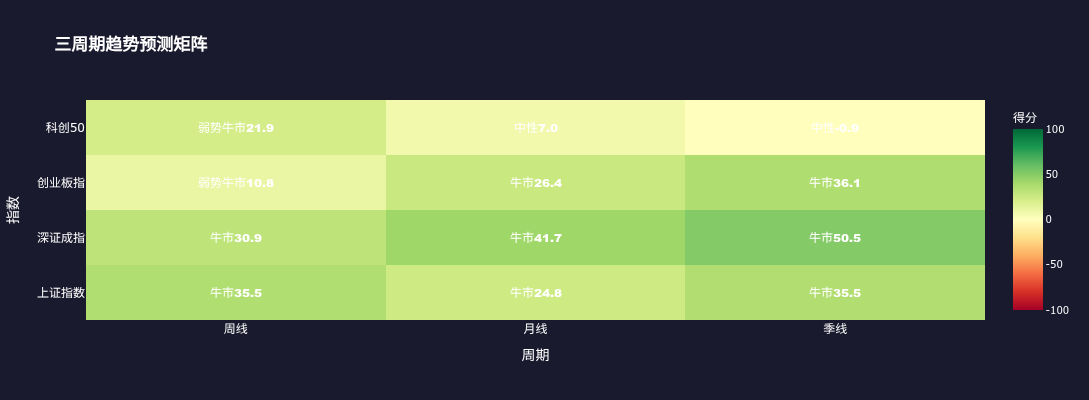

In [15]:
def create_period_matrix(env_results: dict, index_config: dict) -> go.Figure:
    indices = [index_config[s]['name'] for s in env_results.keys()]
    periods = ['周线', '月线', '季线']
    
    z_data, text_data = [], []
    for symbol, result in env_results.items():
        row_z, row_text = [], []
        for p in [result.weekly, result.monthly, result.quarterly]:
            row_z.append(p.score)
            row_text.append(f"{p.environment.value}{p.score:.1f}")
        z_data.append(row_z)
        text_data.append(row_text)
    
    # 使用更清晰的预设颜色方案（RdYlGn：红-黄-绿）
    # 由于z的范围是-100到100，我们需要自定义colorscale来映射这个范围
    fig = go.Figure(data=go.Heatmap(
        z=z_data, x=periods, y=indices, text=text_data, texttemplate="%{text}",
        textfont=dict(size=12, color='white', family='Arial Black'),
        colorscale='RdYlGn',  # 使用预设的红-黄-绿颜色方案，更清晰
        zmid=0, zmin=-100, zmax=100,
        colorbar=dict(
            title=dict(text='得分', font=dict(size=12, color='white')),
            tickvals=[-100, -50, 0, 50, 100],
            tickfont=dict(size=10, color='white'),
            tickmode='array',
            ticktext=['-100', '-50', '0', '50', '100']
        ),
        hoverongaps=False
    ))
    
    fig.update_layout(
        title='<b>三周期趋势预测矩阵</b>', xaxis_title='周期', yaxis_title='指数',
        height=400, paper_bgcolor='#1a1a2e', plot_bgcolor='#1a1a2e', font=dict(color='white')
    )
    return fig

if env_results:
    fig_period = create_period_matrix(env_results, INDEX_CONFIG)
    fig_period.show()

## 🔟 多指数技术走势对比

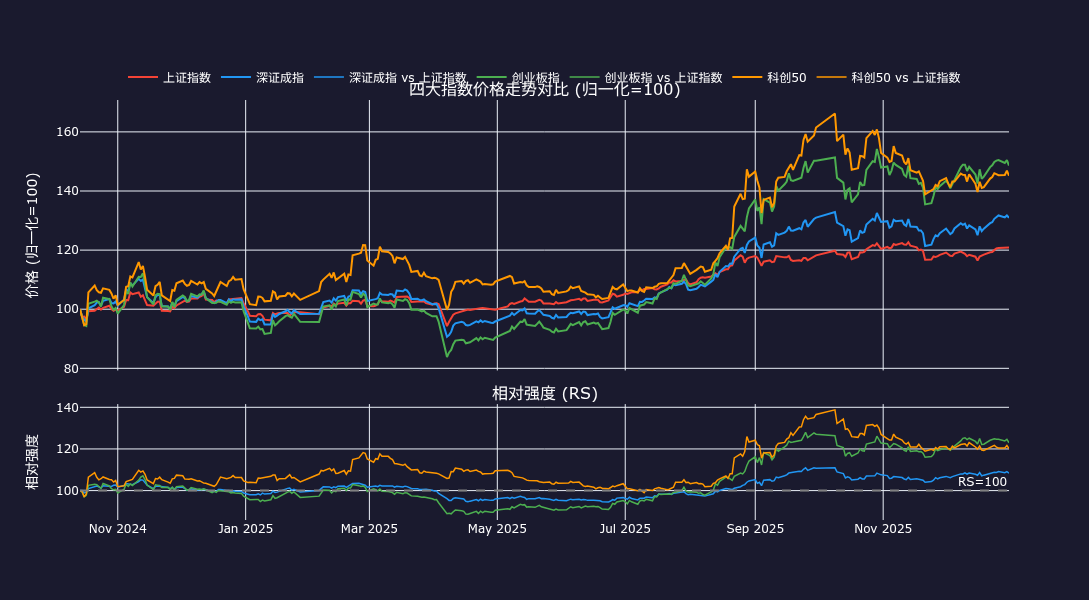

In [16]:
ce = ChartEngine(backend='plotly')
named_data = {INDEX_CONFIG[s]['name']: df for s, df in data_dict.items()}

fig_price = ce.plot_multi_index_comparison(
    data_dict=named_data, chart_type='price', normalize=True,
    title='四大指数价格走势对比 (归一化=100)', height=600
)
if fig_price:
    fig_price.update_layout(paper_bgcolor='#1a1a2e', plot_bgcolor='#1a1a2e', font=dict(color='white'))
    fig_price.show()

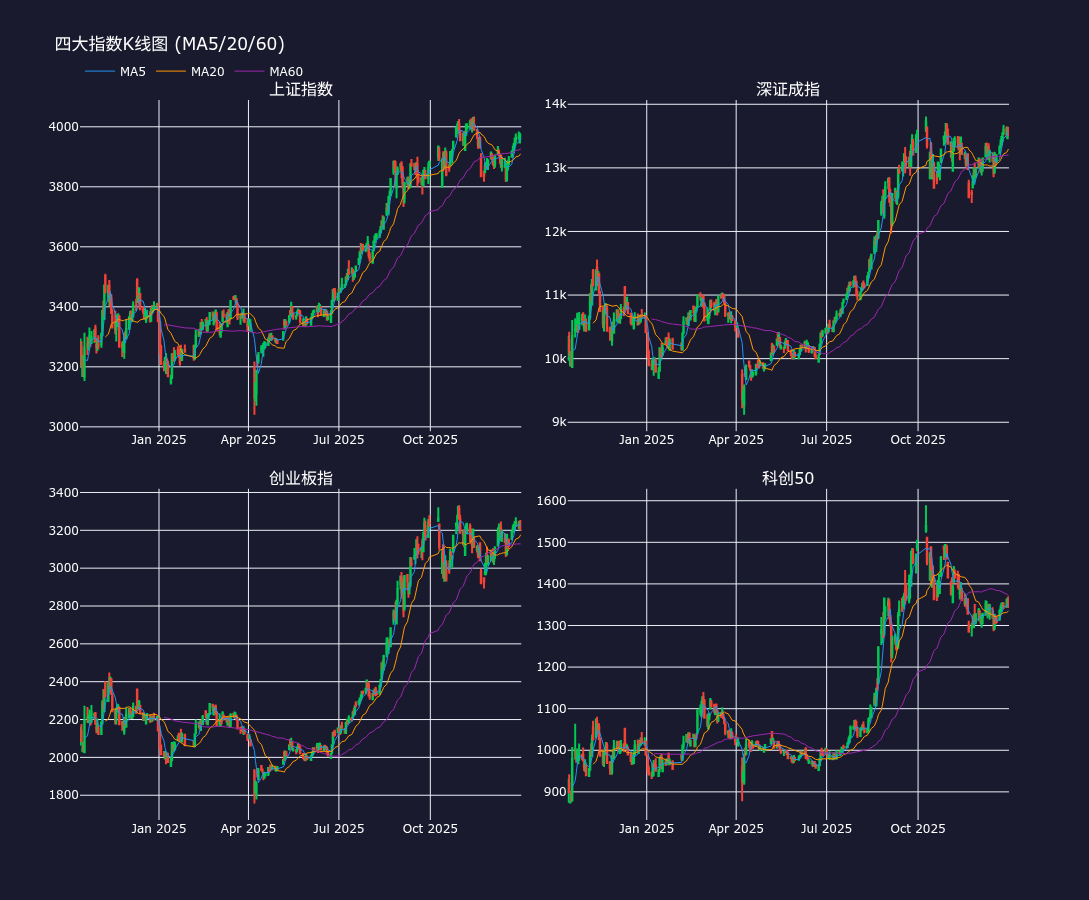

In [17]:
fig_kline = ce.plot_multi_index_kline_grid(
    data_dict=named_data, ma_periods=[5, 20, 60],
    title='四大指数K线图 (MA5/20/60)', height=900
)
if fig_kline:
    fig_kline.update_layout(paper_bgcolor='#1a1a2e', plot_bgcolor='#1a1a2e', font=dict(color='white'))
    fig_kline.show()

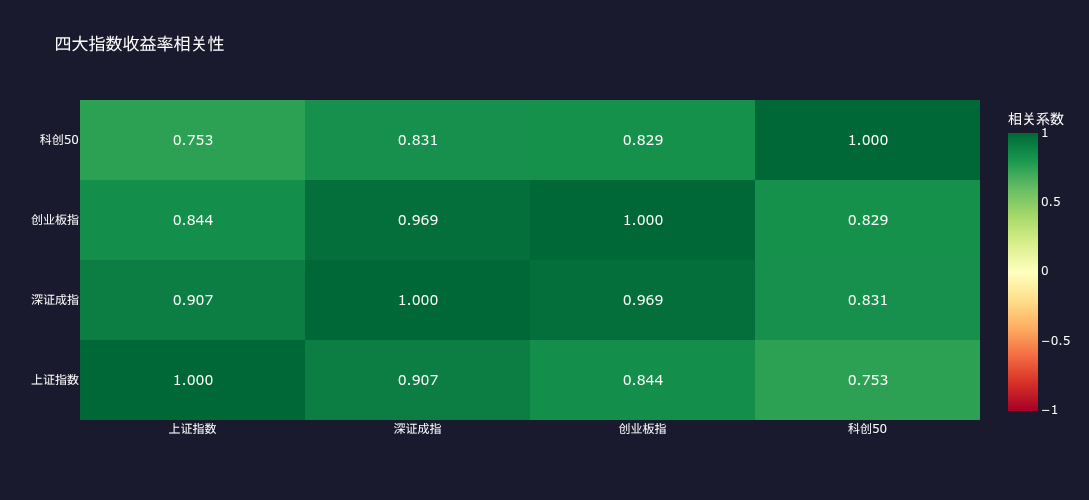

In [18]:
fig_corr = ce.plot_multi_index_comparison(data_dict=named_data, chart_type='correlation', title='四大指数收益率相关性')
if fig_corr:
    fig_corr.update_layout(paper_bgcolor='#1a1a2e', plot_bgcolor='#1a1a2e', font=dict(color='white'))
    fig_corr.show()

## 1️⃣1️⃣ 下游操作参数表

In [19]:
if '000001.XSHG' in env_results:
    result = env_results['000001.XSHG']
    params = get_params_from_result(result)
    print(format_params_summary(params))

市场环境: 牛市 (bull)

【仓位管理】
  建议仓位: 70% (60% ~ 80%)
  单股上限: 12%
  最大持仓: 10只

【风险控制】
  风险等级: low
  止损线: 10%
  止盈线: 30%
  移动止损: 6%
  最大回撤: 15%

【调仓设置】
  调仓频率: weekly
  触发阈值: 8%

【买入条件】
  顺势而为，回调买入
  - 均线: 价格>MA20，MA20向上
  - RSI: (35, 75)

【卖出条件】
  目标止盈+移动止损结合
  - 止损类型: trailing
  - 止盈类型: target

【行业配置】
  偏好: 科技, 消费, 金融
  回避: 周期弱势行业

【操作建议】
  牛市阶段，保持较高仓位。顺势操作，回调加仓。关注领涨板块和龙头个股。

【关注指标】
  MA20趋势, 板块强度, 资金流向, 北向资金


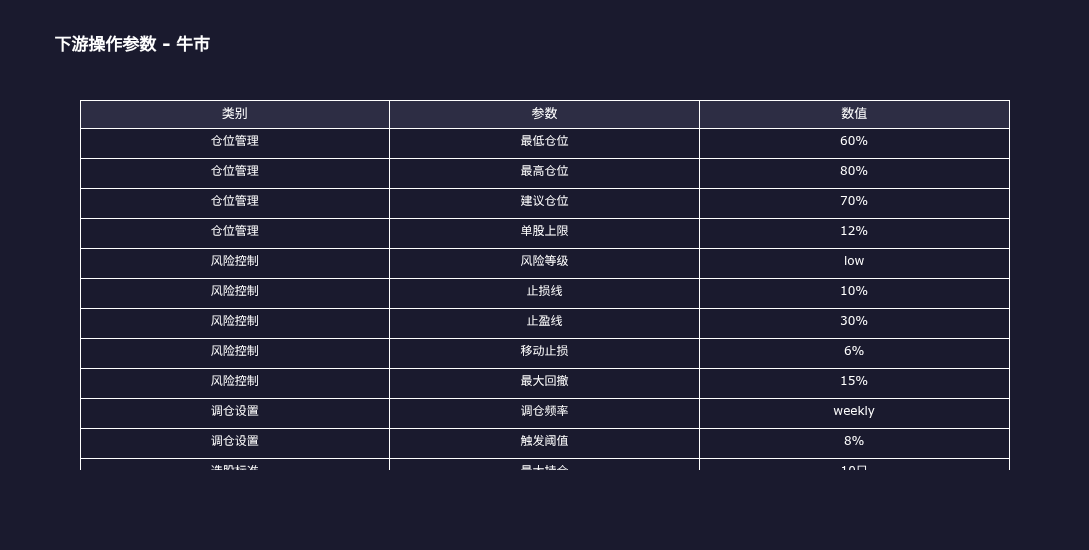

In [20]:
def create_params_table(params) -> go.Figure:
    categories = ['仓位管理']*4 + ['风险控制']*5 + ['调仓设置']*2 + ['选股标准']*3
    items = ['最低仓位', '最高仓位', '建议仓位', '单股上限',
             '风险等级', '止损线', '止盈线', '移动止损', '最大回撤',
             '调仓频率', '触发阈值', '最大持仓', '最小市值', '流动性要求']
    values = [
        f"{params.position_min:.0%}", f"{params.position_max:.0%}",
        f"{params.suggested_position:.0%}", f"{params.single_stock_max:.0%}",
        params.risk_level, f"{params.stop_loss_pct:.0%}", f"{params.take_profit_pct:.0%}",
        f"{params.trailing_stop_pct:.0%}", f"{params.drawdown_limit:.0%}",
        params.rebalance_frequency, f"{params.rebalance_threshold:.0%}",
        f"{params.max_holdings}只", f"{params.min_market_cap}亿", params.liquidity_requirement
    ]
    
    fig = go.Figure(data=[go.Table(
        header=dict(values=['类别', '参数', '数值'], fill_color='#2d2d44', font=dict(color='white', size=13), align='center'),
        cells=dict(values=[categories, items, values], fill_color='#1a1a2e', font=dict(color='white', size=12), align='center', height=30)
    )])
    fig.update_layout(title=f'<b>下游操作参数 - {params.environment_name}</b>', height=550, paper_bgcolor='#1a1a2e', font=dict(color='white'))
    return fig

if '000001.XSHG' in env_results:
    fig_params = create_params_table(params)
    fig_params.show()

## 1️⃣2️⃣ 操作建议汇总

In [21]:
if '000001.XSHG' in env_results:
    print("=" * 60)
    print(f"📊 当前市场环境: {params.environment_name}")
    print("=" * 60)
    print(f"📋 操作建议:   {params.operation_advice}")
    print(f"🎯 关注指标: {', '.join(params.key_indicators)}")
    print(f"✅ 偏好行业: {', '.join(params.industry_preference)}")
    print(f"❌ 回避行业: {', '.join(params.industry_avoid)}")
    print("" + "=" * 60)

📊 当前市场环境: 牛市
📋 操作建议:   牛市阶段，保持较高仓位。顺势操作，回调加仓。关注领涨板块和龙头个股。
🎯 关注指标: MA20趋势, 板块强度, 资金流向, 北向资金
✅ 偏好行业: 科技, 消费, 金融
❌ 回避行业: 周期弱势行业


## 1️⃣3️⃣ 交互式更新

In [22]:
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    WIDGETS_AVAILABLE = True
except ImportError:
    WIDGETS_AVAILABLE = False
    print("⚠️ ipywidgets 未安装")

if WIDGETS_AVAILABLE and env_results:
    index_dropdown = widgets.Dropdown(
        options=[(INDEX_CONFIG[s]['name'], s) for s in env_results.keys()],
        value=list(env_results.keys())[0], description='选择指数:'
    )
    output = widgets.Output()
    
    def on_index_change(change):
        with output:
            clear_output(wait=True)
            symbol = change['new']
            if symbol in env_results:
                r = env_results[symbol]
                print(f"📊 {INDEX_CONFIG[symbol]['name']} 市场环境分析")
                print(f"   综合环境: {r.combined_environment.value}")
                print(f"   综合得分: {r.combined_score:.1f}")
                print(f"   置信度: {r.combined_confidence:.1%}")
                print(f"   建议仓位: {r.position_min:.0%} ~ {r.position_max:.0%}")
                print(f"   风险等级: {r.risk_level}")
                print(f"   周线: {r.weekly.environment.value} ({r.weekly.score:.1f})")
                print(f"   月线: {r.monthly.environment.value} ({r.monthly.score:.1f})")
                print(f"   季线: {r.quarterly.environment.value} ({r.quarterly.score:.1f})")
    
    index_dropdown.observe(on_index_change, names='value')
    display(index_dropdown)
    display(output)
    on_index_change({'new': list(env_results.keys())[0]})

Dropdown(description='选择指数:', options=(('上证指数', '000001.XSHG'), ('深证成指', '399001.XSHE'), ('创业板指', '399006.XSHE…

Output()

---
## 📝 总结

| 功能 | 说明 |
|------|------|
| 状态定义 | 14种市场状态分4大类别 |
| 核心算法 | TrendAnalyzer(80%) + HMM(20%) |
| 多指数 | 上证/深证/创业板/科创50 |
| 三周期 | 周/月/季独立判断 |
| 可视化 | ChartEngine + MarketGauge |
| 下游参数 | 仓位/风险/买卖条件 |